# Coordinate To Image Training

This notebook is only the orchestration layer.
The actual code lives in:
- `model/load.py`
- `model/model.py`
- `model/train.py`
- `model/checkpoints.py`

The defaults here are intentionally conservative so the notebook is less likely to OOM on a busy 8GB GPU.


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == 'model' else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from model.checkpoints import latest_checkpoint, list_checkpoints
from model.load import FingerVideoDataset, discover_processed_dirs
from model.model import CoordinateToImageUNet
from model.train import (
    load_checkpoint,
    make_train_val_test_loaders,
    predict_frames,
    train_or_load_model,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('repo_root:', repo_root)
print('device:', device)


repo_root: /workspace/worldmodel
device: cuda


In [7]:
if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    print('gpu:', torch.cuda.get_device_name(0))
    print('free_gb:', round(free_bytes / 1024**3, 2))
    print('total_gb:', round(total_bytes / 1024**3, 2))
    if free_bytes < 2 * 1024**3:
        print('Warning: GPU is pretty full. Consider waiting for background jobs to finish or lowering batch/model size further.')


gpu: NVIDIA GeForce RTX 3060 Ti
free_gb: 3.89
total_gb: 7.78


In [19]:
DATA_ROOT = repo_root / 'data'
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 4
EPOCHS = 25
LR = 1e-3
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
CHECKPOINT_ROOT = repo_root / 'model/checkpoints'
RUN_NAME = 'coord_to_image_unet'
PREFER_EXISTING_CHECKPOINT = False
BASE_CHANNELS = 16
LATENT_CHANNELS = 128

processed_dirs = discover_processed_dirs(DATA_ROOT)
print('processed dirs:')
for path in processed_dirs:
    print(' -', path)

dataset = FingerVideoDataset(DATA_ROOT, image_size=IMAGE_SIZE)
print('total dataset size:', len(dataset))
print('latest matching checkpoint:', latest_checkpoint(root=CHECKPOINT_ROOT, glob_pattern=f'{RUN_NAME}*.pt'))

train_loader, val_loader, test_loader = make_train_val_test_loaders(
    DATA_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
)

sample_coords, sample_frame = dataset[0]
print('sample coords shape:', sample_coords.shape)
print('sample frame shape:', sample_frame.shape)


processed dirs:
 - /workspace/worldmodel/data/processed-finger-sam-2026-01-30T22-41-47-949Z
 - /workspace/worldmodel/data/processed-finger-sam-2026-03-13T19-37-43-620Z
 - /workspace/worldmodel/data/processed-finger-sam-2026-03-13T19-38-56-625Z
 - /workspace/worldmodel/data/processed-finger-sam-2026-03-13T19-39-13-235Z
 - /workspace/worldmodel/data/processed-finger-sam-2026-03-13T19-46-47-306Z
 - /workspace/worldmodel/data/processed-finger-sam-2026-03-13T19-47-22-023Z
total dataset size: 2749
latest matching checkpoint: /workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T20-33-38Z.pt
sample coords shape: torch.Size([2])
sample frame shape: torch.Size([3, 64, 64])


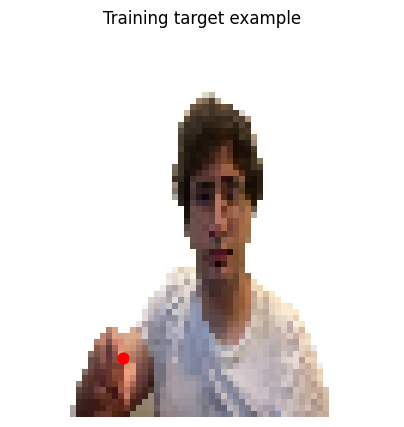

In [20]:
coords, frame = dataset[10]
img = frame.permute(1, 2, 0).cpu().numpy()
x = coords[0].item() * img.shape[1]
y = coords[1].item() * img.shape[0]

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.scatter([x], [y], c='red', s=60)
plt.title('Training target example')
plt.axis('off')
plt.show()


In [21]:
model = CoordinateToImageUNet(
    image_size=IMAGE_SIZE[0],
    base_channels=BASE_CHANNELS,
    latent_channels=LATENT_CHANNELS,
)
model, history, loaded_extra, checkpoint_path, loaded_from_checkpoint = train_or_load_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    run_name=RUN_NAME,
    checkpoint_root=CHECKPOINT_ROOT,
    prefer_existing_checkpoint=PREFER_EXISTING_CHECKPOINT,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    extra={
        'run_name': RUN_NAME,
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
        'base_channels': BASE_CHANNELS,
        'latent_channels': LATENT_CHANNELS,
        'data_root': str(DATA_ROOT),
        'val_fraction': VAL_FRACTION,
        'test_fraction': TEST_FRACTION,
    },
)
print('checkpoint path:', checkpoint_path)
print('loaded_from_checkpoint:', loaded_from_checkpoint)
print('loaded_extra:', loaded_extra)


epoch 001 | train_loss=0.124310 | val_loss=0.104252 | test_loss=0.099464
epoch 002 | train_loss=0.093556 | val_loss=0.097917 | test_loss=0.098714
epoch 003 | train_loss=0.089808 | val_loss=0.092640 | test_loss=0.090321
epoch 004 | train_loss=0.086252 | val_loss=0.093722 | test_loss=0.088499
epoch 005 | train_loss=0.084455 | val_loss=0.088936 | test_loss=0.085889
epoch 006 | train_loss=0.083174 | val_loss=0.090816 | test_loss=0.087938
epoch 007 | train_loss=0.082158 | val_loss=0.087630 | test_loss=0.082922
epoch 008 | train_loss=0.080591 | val_loss=0.087224 | test_loss=0.083493
epoch 009 | train_loss=0.079957 | val_loss=0.086425 | test_loss=0.079969
epoch 010 | train_loss=0.079544 | val_loss=0.086682 | test_loss=0.080175
epoch 011 | train_loss=0.078565 | val_loss=0.085961 | test_loss=0.079115
epoch 012 | train_loss=0.079439 | val_loss=0.085694 | test_loss=0.079197
epoch 013 | train_loss=0.077509 | val_loss=0.085753 | test_loss=0.078017
epoch 014 | train_loss=0.076969 | val_loss=0.087281

In [22]:
all_checkpoints = list_checkpoints(root=CHECKPOINT_ROOT)
for info in all_checkpoints:
    print(info.path)


/workspace/worldmodel/model/checkpoints/auto_save_smoke_2026-03-13T19-20-12Z.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T19-20-32Z.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T20-33-38Z.pt
/workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T21-04-20Z.pt


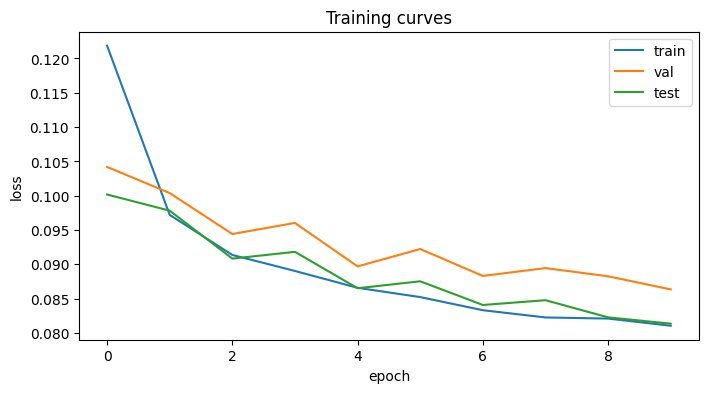

In [14]:
if history is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(history.train_losses, label='train')
    plt.plot(history.val_losses, label='val')
    plt.plot(history.test_losses, label='test')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Training curves')
    plt.legend()
    plt.show()
else:
    print('No new training run happened in this session because an existing checkpoint was loaded.')


In [23]:
model_kwargs = {
    'image_size': IMAGE_SIZE[0],
    'base_channels': loaded_extra.get('base_channels', BASE_CHANNELS) if loaded_extra else BASE_CHANNELS,
    'latent_channels': loaded_extra.get('latent_channels', LATENT_CHANNELS) if loaded_extra else LATENT_CHANNELS,
}
reloaded_model = CoordinateToImageUNet(**model_kwargs).to(device)
reloaded_model, reloaded_history, reloaded_extra = load_checkpoint(
    checkpoint_path,
    reloaded_model,
    device=device,
)
print('reloaded checkpoint from', checkpoint_path)
print('reloaded extra:', reloaded_extra)


reloaded checkpoint from /workspace/worldmodel/model/checkpoints/coord_to_image_unet_2026-03-13T21-04-20Z.pt
reloaded extra: {'run_name': 'coord_to_image_unet', 'image_size': (64, 64), 'batch_size': 4, 'epochs': 25, 'lr': 0.001, 'base_channels': 16, 'latent_channels': 128, 'data_root': '/workspace/worldmodel/data', 'val_fraction': 0.1, 'test_fraction': 0.1}


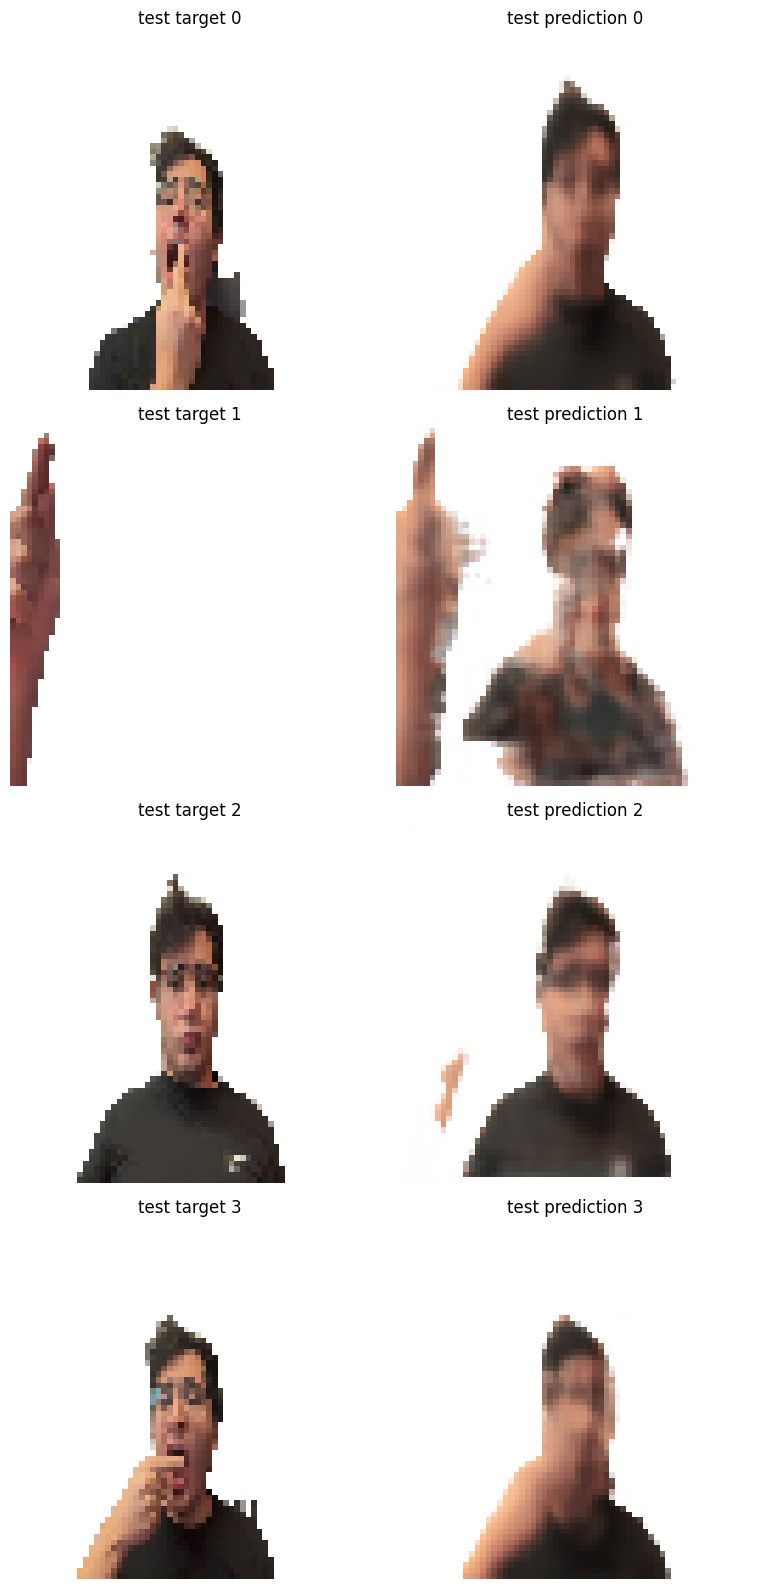

In [24]:
test_coords, test_frames = next(iter(test_loader))
pred_frames = predict_frames(reloaded_model, test_coords[:4], device=device)
target_frames = test_frames[:4]

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for row in range(4):
    target = target_frames[row].permute(1, 2, 0).cpu().numpy()
    pred = pred_frames[row].permute(1, 2, 0).cpu().numpy()
    axes[row, 0].imshow(target)
    axes[row, 0].set_title(f'test target {row}')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(pred)
    axes[row, 1].set_title(f'test prediction {row}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()
